In [26]:
%pip install -q transformers datasets accelerate evaluate seqeval ftfy nltk pandas numpy optuna matplotlib


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
%pip install sentencepiece tiktoken


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import random
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import glob
import shutil
import nltk
import ftfy
from datasets import Dataset
from nltk.tokenize import sent_tokenize
from transformers import (
    AutoTokenizer, 
    AutoModelForTokenClassification,
    BertForTokenClassification,
    TrainingArguments, 
    Trainer,
    DataCollatorForTokenClassification,
    EarlyStoppingCallback,
    TrainerCallback,
    PrinterCallback
)
import evaluate
import optuna

os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
from transformers import logging as tf_logging
tf_logging.set_verbosity_error()
tf_logging.disable_progress_bar()

from datasets import logging as ds_logging
ds_logging.set_verbosity_error()
ds_logging.disable_progress_bar()

optuna.logging.set_verbosity(optuna.logging.WARNING)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")


Using device: cuda


In [3]:
print("Loading EE21/ToS-Summaries...")
df_summaries = pd.read_json("hf://datasets/EE21/ToS-Summaries/dataset.json", lines=True)

print("Loading CodeHima/TOS_Dataset...")
splits = {'train': 'data/train-00000-of-00001.parquet'}
df_codehima = pd.read_parquet("hf://datasets/CodeHima/TOS_Dataset/" + splits["train"])

print("Data loaded successfully!")

Loading EE21/ToS-Summaries...
Loading CodeHima/TOS_Dataset...
Data loaded successfully!


In [ ]:
try:
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    nltk.download('punkt_tab', quiet=True)

def parse_all_datasets(df_codehima):
    standardized_data = []

    print("Parsing CodeHima...")
    neutral_sentences = []
    gotcha_sentences = []
    for _, row in df_codehima.iterrows():
        sentence = str(row['sentence'])
        if row['unfairness_level'] in ['potentially_unfair', 'clearly_unfair']:
            gotcha_sentences.append(sentence)
        else:
            neutral_sentences.append(sentence)
            standardized_data.append({"text": sentence, "gotchas": []})

    random.seed(42)
    for gotcha_sent in gotcha_sentences:
        context_sent = random.choice(neutral_sentences)
        combined_text = context_sent + ' ' + gotcha_sent
        standardized_data.append({"text": combined_text, "gotchas": [gotcha_sent]})
    print(f"  CodeHima: {len(neutral_sentences)} neutral, {len(gotcha_sentences)} gotcha (wrapped in context)")

    return Dataset.from_list(standardized_data)

raw_original_dataset = parse_all_datasets(df_codehima)

dataset_splits = raw_original_dataset.train_test_split(test_size=0.15, seed=42)

synthetic_path = "corpus/synthetic_gotchas.json"
if os.path.exists(synthetic_path):
    import json
    from datasets import Dataset, concatenate_datasets
    print(f"Loading synthetic data from {synthetic_path}...")
    try:
        with open(synthetic_path, "r", encoding="utf-8") as f:
            synthetic_data = json.load(f)
        print(f"Adding {len(synthetic_data)} synthetic training samples exclusively to the training split.")

        synthetic_dataset = Dataset.from_list(synthetic_data)
        original_train = dataset_splits["train"]
        dataset_splits["train"] = concatenate_datasets([original_train, synthetic_dataset])
        print(f"Merged training split size: {len(dataset_splits['train'])} samples (Original: {len(original_train)}, Synthetic: {len(synthetic_dataset)})")
    except Exception as e:
        print(f"Error loading or merging synthetic data: {e}")
else:
    print("No synthetic gotchas found. Training on baseline splits.")

print(f"Parsed dataset: train={len(dataset_splits['train'])}, test={len(dataset_splits['test'])}")

Parsing CodeHima...
  CodeHima: 4365 neutral, 1013 gotcha (wrapped in context)
Parsing EE21...
  EE21: 847 gotcha, 54 neutral
Loading synthetic data from corpus/synthetic_gotchas.json...
Adding 3479 synthetic training samples exclusively to the training split.
Merged training split size: 8816 samples (Original: 5337, Synthetic: 3479)
Parsed dataset: train=8816, test=942


In [5]:
label2id = {'O': 0, 'B-RISK': 1, 'I-RISK': 2}
id2label = {0: 'O', 1: 'B-RISK', 2: 'I-RISK'}

def tokenize_and_align_labels(example, tokenizer):
    text = example['text']
    gotchas = example['gotchas']

    tokenized_inputs = tokenizer(
        text, 
        truncation=True, 
        max_length=512, 
        return_offsets_mapping=True
    )

    offsets = tokenized_inputs["offset_mapping"]
    labels = [label2id['O']] * len(offsets)

    for gotcha in gotchas:
        start_char = text.find(gotcha)
        if start_char == -1: continue
        end_char = start_char + len(gotcha)

        gotcha_started = False
        for idx, (start, end) in enumerate(offsets):
            if start == end: 
                labels[idx] = -100
                continue

            if start >= start_char and start < end_char:
                if not gotcha_started:
                    labels[idx] = label2id['B-RISK']
                    gotcha_started = True
                else:
                    labels[idx] = label2id['I-RISK']

    tokenized_inputs["labels"] = labels
    del tokenized_inputs["offset_mapping"]
    return tokenized_inputs

In [6]:

TOKENIZER_MAP = {
    "prajjwal1/bert-tiny": "google-bert/bert-base-uncased",
    "prajjwal1/bert-mini": "google-bert/bert-base-uncased",
}

MODEL_CLASS_MAP = {
    "prajjwal1/bert-tiny": BertForTokenClassification,
    "prajjwal1/bert-mini": BertForTokenClassification,
}

MODEL_ARCH_MAP = {
    "google/electra-small-discriminator": {"backbone_attr": "electra", "max_layers": 12},
    "prajjwal1/bert-tiny":                {"backbone_attr": "bert",   "max_layers": 2},
    "prajjwal1/bert-mini":                {"backbone_attr": "bert",   "max_layers": 4},
    "huawei-noah/TinyBERT_General_4L_312D": {"backbone_attr": "bert", "max_layers": 4},
}


In [7]:
metric = evaluate.load("seqeval")

class TrialMetricsCallback(TrainerCallback):
    """Collects eval metrics per epoch per trial. Call display() after search to render tables."""
    def __init__(self):
        self.all_trials = {}
        self._trial_num = 0
        self._current = []

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs and "eval_loss" in logs:
            self._current.append({
                "Epoch": int(state.epoch) if state.epoch == int(state.epoch) else round(state.epoch, 2),
                "Loss": round(logs.get("eval_loss", 0), 4),
                "Precision": round(logs.get("eval_precision", 0), 4),
                "Recall": round(logs.get("eval_recall", 0), 4),
                "F1": round(logs.get("eval_f1", 0), 4),
                "Accuracy": round(logs.get("eval_accuracy", 0), 4),
            })

    def on_train_end(self, args, state, control, **kwargs):
        if self._current:
            self.all_trials[self._trial_num] = self._current
            self._trial_num += 1
            self._current = []

    def display(self, label_prefix="Trial"):
        from IPython.display import display as ipy_display, HTML
        for trial_num, metrics in sorted(self.all_trials.items()):
            df = pd.DataFrame(metrics)
            if not df.empty:
                best_idx = df["F1"].idxmax()
                best_f1 = df.loc[best_idx, "F1"]
                best_epoch = df.loc[best_idx, "Epoch"]
                ipy_display(HTML(f"<b>\u250c\u2500 {label_prefix} {trial_num + 1} \u2500 Best F1: {best_f1:.4f} (Epoch {int(best_epoch)})</b>"))
                ipy_display(df)

    def reset(self):
        self.all_trials = {}
        self._trial_num = 0
        self._current = []

def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    true_predictions = [
        [id2label[p] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]
    true_labels = [
        [id2label[l] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]
    results = metric.compute(predictions=true_predictions, references=true_labels)
    return {
        "precision": results["overall_precision"],
        "recall": results["overall_recall"],
        "f1": results["overall_f1"],
        "accuracy": results["overall_accuracy"],
    }


In [8]:
class WeightedLossTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        device = logits.device

        loss_fct = torch.nn.CrossEntropyLoss(
            weight=torch.tensor([0.38, 4.70, 1.00], device=device)
        )

        if labels is not None:
            active_loss = inputs.get("attention_mask").view(-1) == 1
            active_logits = logits.view(-1, self.model.config.num_labels)
            active_labels = torch.where(
                active_loss, labels.view(-1),
                torch.tensor(-100, device=device)
            )
            loss = loss_fct(active_logits, active_labels)
        else:
            loss = outputs.loss

        return (loss, outputs) if return_outputs else loss


In [9]:

def freeze_layers(model, model_checkpoint, num_frozen_layers):
    """Dynamically freeze embeddings + the specified number of bottom encoder layers."""
    arch = MODEL_ARCH_MAP.get(model_checkpoint)
    if arch is None:
        return

    backbone = getattr(model, arch["backbone_attr"], None)
    if backbone is None:
        return

    for param in backbone.embeddings.parameters():
        param.requires_grad = False

    if hasattr(backbone, "encoder") and hasattr(backbone.encoder, "layer"):
        actual_layers = len(backbone.encoder.layer)
        num_to_freeze = min(num_frozen_layers, actual_layers)
        for i in range(num_to_freeze):
            for param in backbone.encoder.layer[i].parameters():
                param.requires_grad = False

def optuna_train_model(model_checkpoint, save_name, n_trials=10, num_epochs=10):
    """Run Optuna hyperparameter search, then retrain with best hyperparameters."""
    print(f"\n{'='*60}")
    print(f"  OPTUNA SEARCH: {model_checkpoint} ({n_trials} trials, {num_epochs} epochs each)")
    print(f"{'='*60}")

    output_dir = f"./gotcha-extractor-model/{save_name}"
    search_dir = f"./gotcha-extractor-model/{save_name}-optuna-search"

    tok_name = TOKENIZER_MAP.get(model_checkpoint, model_checkpoint)
    model_cls = MODEL_CLASS_MAP.get(model_checkpoint, AutoModelForTokenClassification)
    tokenizer = AutoTokenizer.from_pretrained(
        tok_name, add_prefix_space="roberta" in model_checkpoint
    )

    tokenized_train = dataset_splits["train"].map(
        lambda x: tokenize_and_align_labels(x, tokenizer),
        remove_columns=dataset_splits["train"].column_names
    )
    tokenized_test = dataset_splits["test"].map(
        lambda x: tokenize_and_align_labels(x, tokenizer),
        remove_columns=dataset_splits["test"].column_names
    )
    data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

    arch = MODEL_ARCH_MAP.get(model_checkpoint)
    max_freezable = arch["max_layers"] if arch else 0

    def model_init(trial=None):
        model = model_cls.from_pretrained(
            model_checkpoint,
            num_labels=len(label2id),
            id2label=id2label,
            label2id=label2id,
            ignore_mismatched_sizes=True
        ).to(device)

        if trial is not None and max_freezable > 0:
            num_frozen = trial.suggest_int("num_frozen_layers", 0, max_freezable)
            freeze_layers(model, model_checkpoint, num_frozen)
            print(f"  [Trial {trial.number}] Freezing embeddings + bottom {num_frozen}/{max_freezable} layers")
        elif trial is not None:
            freeze_layers(model, model_checkpoint, 0)
            print(f"  [Trial {trial.number}] Freezing embeddings only")

        trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
        total = sum(p.numel() for p in model.parameters())
        print(f"  Trainable: {trainable:,} / {total:,}")
        return model

    def hp_space(trial):
        return {
            "learning_rate": trial.suggest_float("learning_rate", 1e-5, 8e-5, log=True),
            "weight_decay": trial.suggest_float("weight_decay", 0.0, 0.15),
            "per_device_train_batch_size": trial.suggest_categorical("per_device_train_batch_size", [8, 16]),
            "warmup_ratio": trial.suggest_float("warmup_ratio", 0.05, 0.25),
        }

    metrics_cb = TrialMetricsCallback()
    search_args = TrainingArguments(
        output_dir=search_dir,
        eval_strategy="epoch",
        learning_rate=5e-5,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        num_train_epochs=num_epochs,
        weight_decay=0.01,
        logging_strategy="no",
        disable_tqdm=True,
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,
        save_total_limit=1,
        warmup_ratio=0.15,
        report_to="none",
    )

    trainer = WeightedLossTrainer(
        model_init=model_init,
        args=search_args,
        train_dataset=tokenized_train,
        eval_dataset=tokenized_test,
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        callbacks=[metrics_cb],
    )
    trainer.remove_callback(PrinterCallback)

    best_run = trainer.hyperparameter_search(
        direction="maximize",
        backend="optuna",
        hp_space=hp_space,
        n_trials=n_trials,
        compute_objective=lambda metrics: metrics["eval_f1"],
    )
    metrics_cb.display(label_prefix="Trial")

    import copy
    search_history = copy.deepcopy(metrics_cb.all_trials)

    print(f"\n{'='*60}")
    print(f"  BEST HYPERPARAMETERS FOUND")
    print(f"{'='*60}")
    for key, value in best_run.hyperparameters.items():
        print(f"  {key}: {value}")
    print(f"  Best F1: {best_run.objective:.4f}")

    print(f"\n>>> Final training with best hyperparameters <<<")

    best_hp = best_run.hyperparameters
    best_frozen = best_hp.pop("num_frozen_layers", max_freezable)

    final_model = model_cls.from_pretrained(
        model_checkpoint,
        num_labels=len(label2id),
        id2label=id2label,
        label2id=label2id,
        ignore_mismatched_sizes=True
    ).to(device)
    freeze_layers(final_model, model_checkpoint, best_frozen)

    trainable = sum(p.numel() for p in final_model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in final_model.parameters())
    print(f"Final model \u2014 Frozen layers: {best_frozen}, Trainable: {trainable:,} / {total:,}")

    metrics_cb.reset()
    final_args = TrainingArguments(
        output_dir=output_dir,
        eval_strategy="epoch",
        learning_rate=best_hp.get("learning_rate", 5e-5),
        per_device_train_batch_size=best_hp.get("per_device_train_batch_size", 8),
        per_device_eval_batch_size=8,
        num_train_epochs=num_epochs,
        weight_decay=best_hp.get("weight_decay", 0.01),
        logging_strategy="no",
        disable_tqdm=True,
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,
        save_total_limit=1,
        warmup_ratio=best_hp.get("warmup_ratio", 0.15),
    )

    final_trainer = WeightedLossTrainer(
        model=final_model,
        args=final_args,
        train_dataset=tokenized_train,
        eval_dataset=tokenized_test,
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        callbacks=[metrics_cb],
    )
    final_trainer.remove_callback(PrinterCallback)

    final_trainer.train()
    metrics_cb.display(label_prefix="Final Training Epoch")

    final_history = copy.deepcopy(metrics_cb.all_trials.get(0, []))

    final_trainer.save_model(output_dir)
    tokenizer.save_pretrained(output_dir)

    try:
        import json
        import os

        def format_history(all_trials_dict):
            formatted = {}
            for t_num, epochs_list in all_trials_dict.items():
                formatted[str(t_num + 1)] = {
                    "epochs": [e["Epoch"] for e in epochs_list],
                    "f1": [e["F1"] for e in epochs_list],
                    "loss": [e["Loss"] for e in epochs_list],
                    "precision": [e["Precision"] for e in epochs_list],
                    "recall": [e["Recall"] for e in epochs_list]
                }
            return formatted

        metrics_data = {
            "trials": format_history(search_history),
            "final_run": {
                "epochs": [e["Epoch"] for e in final_history],
                "f1": [e["F1"] for e in final_history],
                "loss": [e["Loss"] for e in final_history],
                "precision": [e["Precision"] for e in final_history],
                "recall": [e["Recall"] for e in final_history]
            },
            "best_hp": {
                "num_frozen_layers": best_frozen,
                "learning_rate": best_run.hyperparameters.get("learning_rate"),
                "weight_decay": best_run.hyperparameters.get("weight_decay"),
                "batch_size": best_run.hyperparameters.get("per_device_train_batch_size"),
                "warmup_ratio": best_run.hyperparameters.get("warmup_ratio"),
                "best_f1": best_run.objective,
            }
        }

        metrics_file = f"./gotcha-extractor-model/{save_name}_metrics.json"
        os.makedirs(os.path.dirname(metrics_file), exist_ok=True)
        with open(metrics_file, "w", encoding="utf-8") as f:
            json.dump(metrics_data, f, indent=2)
        print(f"Successfully saved training metrics to {metrics_file}")
    except Exception as e:
        print(f"Error saving training metrics JSON: {e}")

    if os.path.exists(search_dir):
        shutil.rmtree(search_dir)
        print(f"Cleaned up search directory: {search_dir}")

    print(f"Finished! Best model saved to {output_dir}")
    return best_run


In [ ]:
optuna_train_model("google/electra-small-discriminator", "electra-small", n_trials=15, num_epochs=10)



  OPTUNA SEARCH: google/electra-small-discriminator (10 trials, 10 epochs each)
  Trainable: 13,483,779 / 13,483,779
  [Trial 0] Freezing embeddings + bottom 9/12 layers
  Trainable: 2,403,075 / 13,483,779
  [Trial 1] Freezing embeddings + bottom 0/12 layers
  Trainable: 9,510,915 / 13,483,779
  [Trial 2] Freezing embeddings + bottom 3/12 layers
  Trainable: 7,141,635 / 13,483,779
  [Trial 3] Freezing embeddings + bottom 10/12 layers
  Trainable: 1,613,315 / 13,483,779
  [Trial 4] Freezing embeddings + bottom 3/12 layers
  Trainable: 7,141,635 / 13,483,779
  [Trial 5] Freezing embeddings + bottom 10/12 layers
  Trainable: 1,613,315 / 13,483,779
  [Trial 6] Freezing embeddings + bottom 7/12 layers
  Trainable: 3,982,595 / 13,483,779
  [Trial 7] Freezing embeddings + bottom 7/12 layers
  Trainable: 3,982,595 / 13,483,779
  [Trial 8] Freezing embeddings + bottom 11/12 layers
  Trainable: 823,555 / 13,483,779
  [Trial 9] Freezing embeddings + bottom 1/12 layers
  Trainable: 8,721,155 / 13

,Epoch,Loss,Precision,Recall,F1,Accuracy
0,1,0.5817,0.0018,0.0162,0.0032,0.8160
1,2,0.4028,0.0265,0.1862,0.0464,0.8737
2,3,0.3595,0.0795,0.4372,0.1345,0.8909
3,4,0.3049,0.0730,0.4534,0.1258,0.8948
4,5,0.2731,0.0709,0.5425,0.1254,0.8828
5,6,0.2886,0.0781,0.5547,0.1369,0.8772
6,7,0.2842,0.0861,0.5101,0.1473,0.8977
7,8,0.2916,0.0906,0.5344,0.1549,0.9024
8,9,0.2929,0.0852,0.5466,0.1475,0.8939
9,10,0.2976,0.0913,0.5547,0.1568,0.8987


,Epoch,Loss,Precision,Recall,F1,Accuracy
0,1,0.5204,0.0088,0.0364,0.0141,0.8663
1,2,0.3337,0.0883,0.4291,0.1465,0.8911
2,3,0.3281,0.1764,0.5628,0.2686,0.9074
3,4,0.3719,0.1995,0.6073,0.3003,0.9120
4,5,0.3144,0.1823,0.6923,0.2886,0.9019
5,6,0.3748,0.2120,0.7126,0.3268,0.9063
6,7,0.4502,0.2548,0.5870,0.3554,0.9140
7,8,0.4543,0.3152,0.6802,0.4308,0.9092
8,9,0.4739,0.3252,0.6478,0.4330,0.9134
9,10,0.4291,0.2902,0.7085,0.4118,0.9134


,Epoch,Loss,Precision,Recall,F1,Accuracy
0,1,0.6406,0.0017,0.0081,0.0028,0.8276
1,2,0.3888,0.0326,0.1903,0.0557,0.8820
2,3,0.3475,0.1036,0.4049,0.1650,0.9008
3,4,0.3410,0.1103,0.4656,0.1783,0.9001
4,5,0.3243,0.0951,0.5547,0.1623,0.8753
5,6,0.3079,0.1240,0.5263,0.2008,0.8989
6,7,0.3216,0.1515,0.5182,0.2344,0.9050
7,8,0.3299,0.1530,0.5506,0.2394,0.9010
8,9,0.3365,0.1639,0.5587,0.2534,0.9030
9,10,0.3307,0.1454,0.5668,0.2314,0.8997


,Epoch,Loss,Precision,Recall,F1,Accuracy
0,1,0.6380,0.0010,0.0121,0.0018,0.7842
1,2,0.5183,0.0063,0.0567,0.0113,0.8367
2,3,0.4198,0.0336,0.2915,0.0603,0.8613
3,4,0.3836,0.0488,0.3968,0.0868,0.8729
4,5,0.3459,0.0502,0.4534,0.0904,0.8642
5,6,0.3381,0.0567,0.4777,0.1014,0.8646
6,7,0.3344,0.0603,0.4737,0.1069,0.8788
7,8,0.3324,0.0586,0.4696,0.1043,0.8769
8,9,0.3372,0.0645,0.4777,0.1137,0.8815
9,10,0.3346,0.0628,0.4696,0.1108,0.8810


...

,Epoch,Loss,Precision,Recall,F1,Accuracy
0,1,0.547,0.0054,0.0324,0.0092,0.8343


,Epoch,Loss,Precision,Recall,F1,Accuracy
0,1,0.8495,0.0,0.0,0.0,0.7988


,Epoch,Loss,Precision,Recall,F1,Accuracy
0,1,0.4807,0.0269,0.1012,0.0425,0.8781
1,2,0.3232,0.0993,0.4818,0.1647,0.8991
2,3,0.3095,0.1588,0.5749,0.2489,0.9023
3,4,0.3606,0.2136,0.6356,0.3198,0.9173
4,5,0.3291,0.2166,0.6964,0.3305,0.9046
5,6,0.3946,0.2540,0.7085,0.3739,0.9135
6,7,0.4061,0.2643,0.6154,0.3698,0.9157
7,8,0.4352,0.2917,0.6518,0.4030,0.9199
8,9,0.4535,0.3052,0.6599,0.4174,0.9188
9,10,0.4347,0.2824,0.6964,0.4019,0.9145



  BEST HYPERPARAMETERS FOUND
  num_frozen_layers: 0
  learning_rate: 3.25403772619166e-05
  weight_decay: 0.13425032573877754
  per_device_train_batch_size: 16
  warmup_ratio: 0.2246663570650131
  Best F1: 0.4118

>>> Final training with best hyperparameters <<<
Final model — Frozen layers: 0, Trainable: 9,510,915 / 13,483,779


KeyboardInterrupt: 

In [13]:
optuna_train_model("prajjwal1/bert-tiny", "bert-tiny", n_trials=15, num_epochs=10)



  OPTUNA SEARCH: prajjwal1/bert-tiny (10 trials, 10 epochs each)
  Trainable: 4,369,795 / 4,369,795
  [Trial 0] Freezing embeddings + bottom 2/2 layers
  Trainable: 387 / 4,369,795


[W 2026-06-03 00:17:04,330] Trial 0 failed with parameters: {'num_frozen_layers': 2, 'learning_rate': 1.2256259067377313e-05, 'weight_decay': 0.016865461179420643, 'per_device_train_batch_size': 16, 'warmup_ratio': 0.2170090684267037} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "d:\VSC\nlp_aol\.venv\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "d:\VSC\nlp_aol\.venv\Lib\site-packages\transformers\integrations\integration_utils.py", line 257, in _objective
    trainer.train(resume_from_checkpoint=checkpoint, trial=trial)
  File "d:\VSC\nlp_aol\.venv\Lib\site-packages\transformers\trainer.py", line 1427, in train
    return inner_training_loop(
           ^^^^^^^^^^^^^^^^^^^^
  File "d:\VSC\nlp_aol\.venv\Lib\site-packages\transformers\trainer.py", line 1509, in _inner_training_loop
    self._run_epoch(
  File "d:\VSC\nlp_aol\.venv\Lib\site-

KeyboardInterrupt: 

In [ ]:
optuna_train_model("huawei-noah/TinyBERT_General_4L_312D", "tinybert", n_trials=15, num_epochs=10)



  OPTUNA SEARCH: huawei-noah/TinyBERT_General_4L_312D (10 trials, 10 epochs each)
  Trainable: 14,253,531 / 14,253,531
  [Trial 0] Freezing embeddings + bottom 1/4 layers
  Trainable: 3,427,491 / 14,253,531


[W 2026-05-30 11:48:34,107] Trial 0 failed with parameters: {'num_frozen_layers': 1, 'learning_rate': 1.3463949089094e-05, 'weight_decay': 0.12284462881893396, 'per_device_train_batch_size': 16, 'warmup_ratio': 0.1806284168048427} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "d:\VSC\nlp_aol\.venv\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "d:\VSC\nlp_aol\.venv\Lib\site-packages\transformers\integrations\integration_utils.py", line 257, in _objective
    trainer.train(resume_from_checkpoint=checkpoint, trial=trial)
  File "d:\VSC\nlp_aol\.venv\Lib\site-packages\transformers\trainer.py", line 1427, in train
    return inner_training_loop(
           ^^^^^^^^^^^^^^^^^^^^
  File "d:\VSC\nlp_aol\.venv\Lib\site-packages\transformers\trainer.py", line 1509, in _inner_training_loop
    self._run_epoch(
  File "d:\VSC\nlp_aol\.venv\Lib\site-pack

KeyboardInterrupt: 

In [ ]:
optuna_train_model("prajjwal1/bert-mini", "bert-mini", n_trials=15, num_epochs=10)


Loading live training metrics from ./gotcha-extractor-model/electra-small_metrics.json for electra-small...


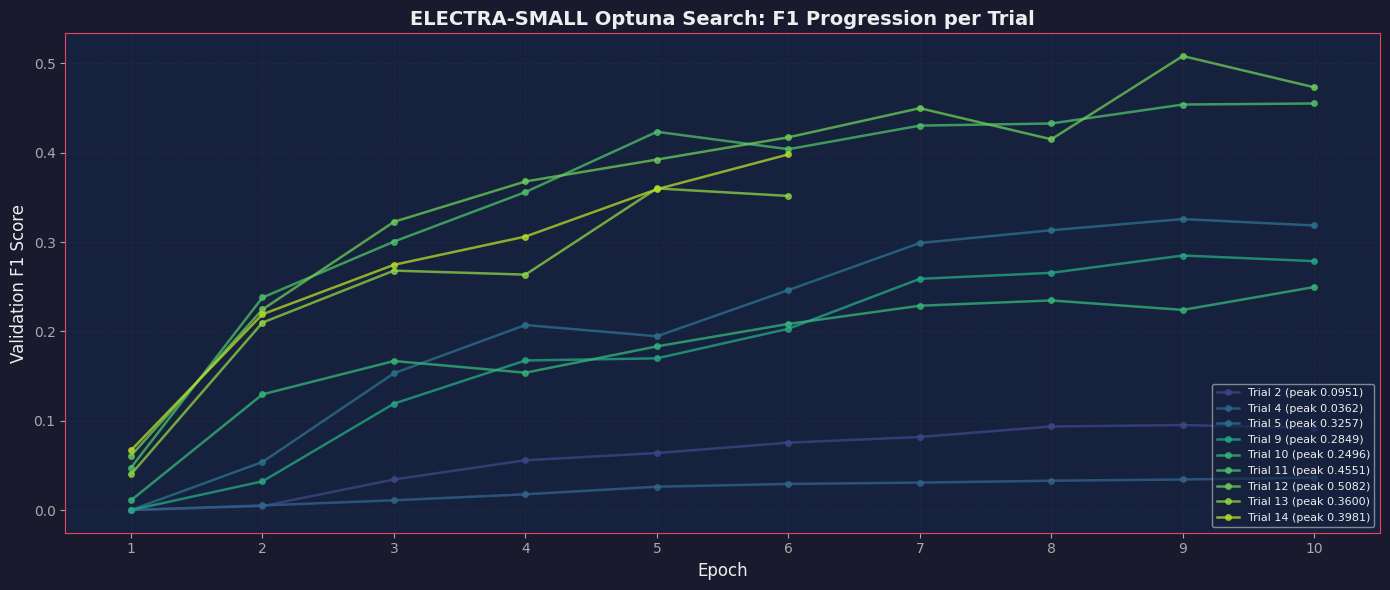

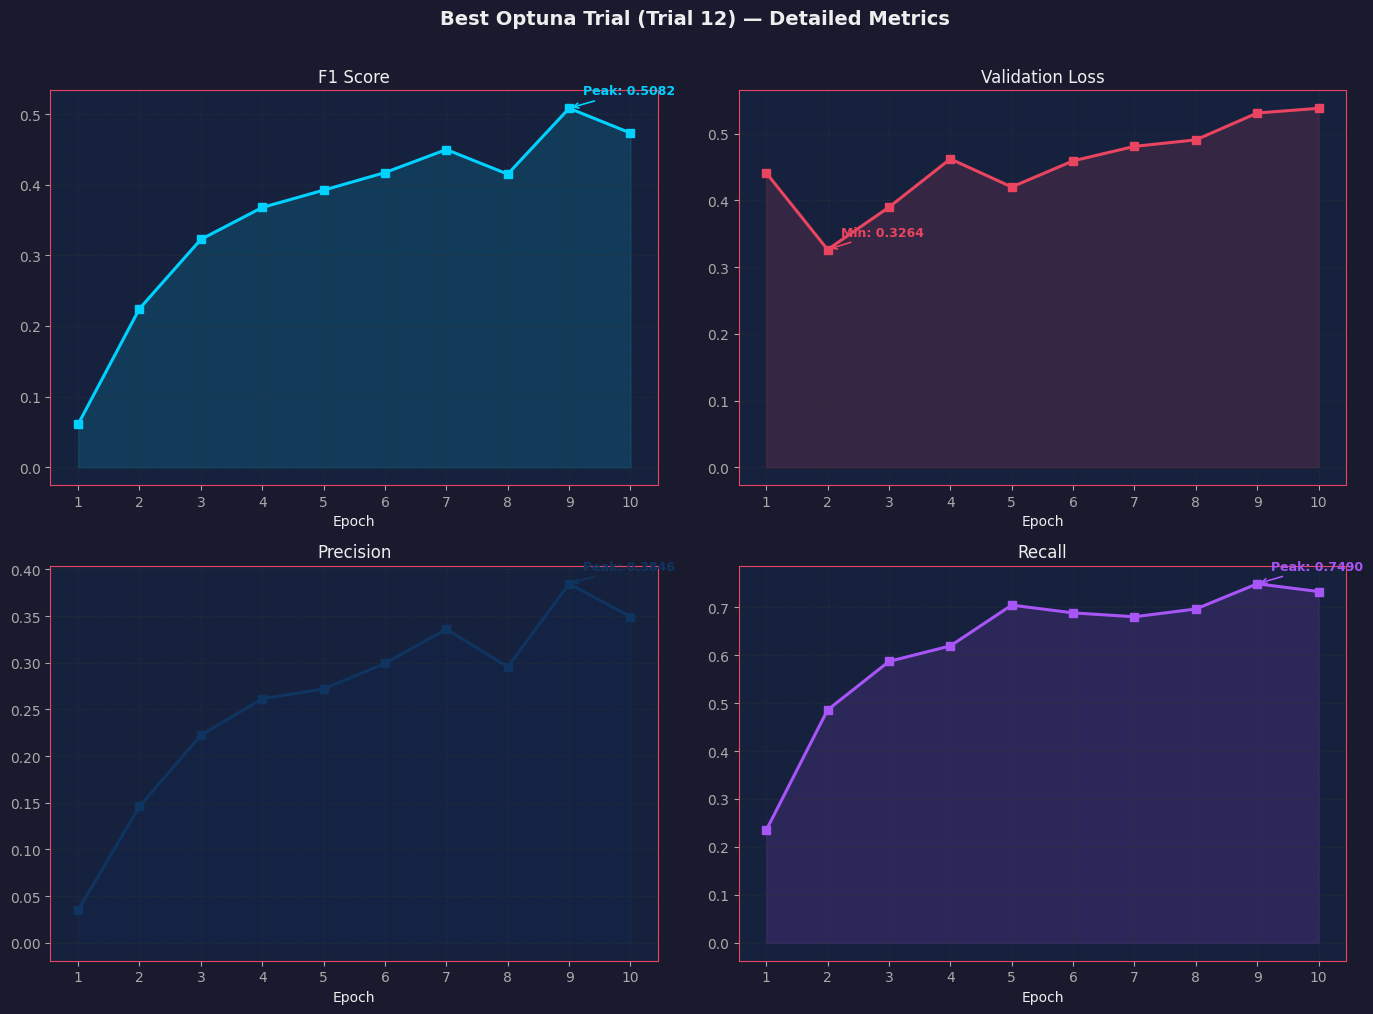

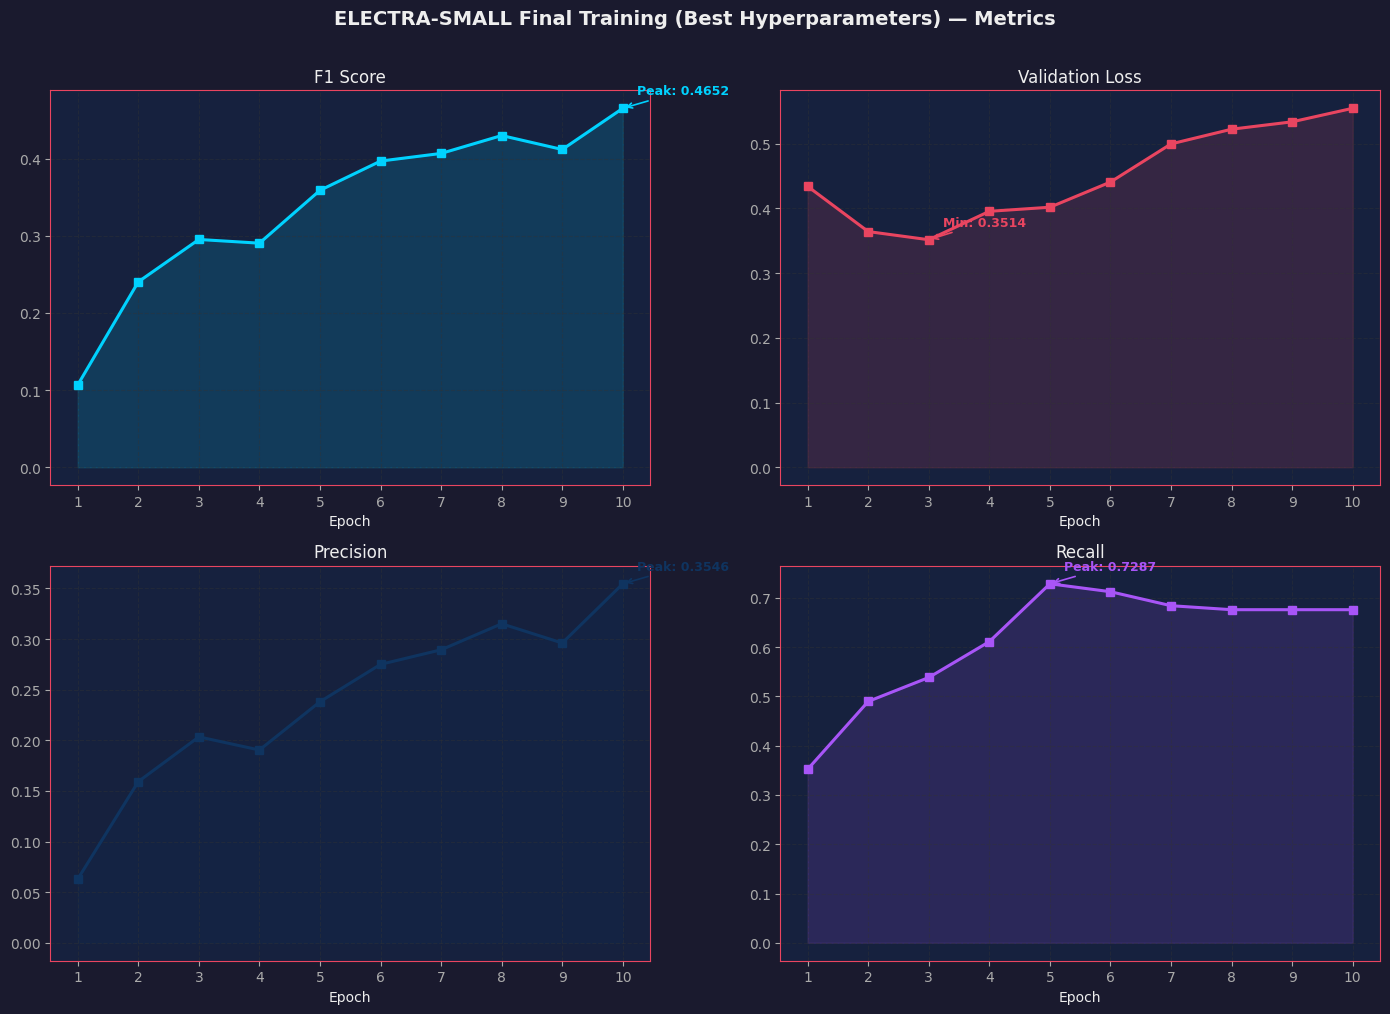

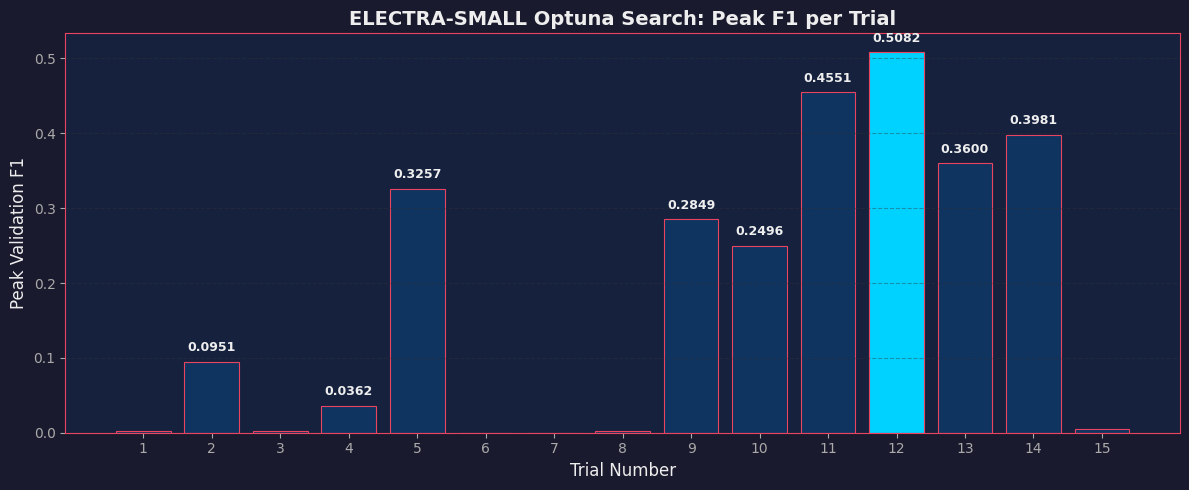


Best Hyperparameters Summary for electra-small:
  num_frozen_layers: 0
  learning_rate: 3.25515750502575e-05
  weight_decay: 0.10843350203717517
  batch_size: 8
  warmup_ratio: 0.11726619706630656
  best_f1: 0.473202614379085


In [32]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import os
import json

model_to_visualize = "electra-small"

plt.rcParams.update({
    'figure.facecolor': '#1a1a2e',
    'axes.facecolor': '#16213e',
    'axes.edgecolor': '#e94560',
    'axes.labelcolor': '#eee',
    'text.color': '#eee',
    'xtick.color': '#aaa',
    'ytick.color': '#aaa',
    'grid.color': '#333',
    'grid.alpha': 0.4,
    'font.family': 'sans-serif',
    'font.size': 10,
})

metrics_file = f"./gotcha-extractor-model/{model_to_visualize}_metrics.json"

print(f"Loading live training metrics from {metrics_file} for {model_to_visualize}...")
with open(metrics_file, "r", encoding="utf-8") as f:
    data = json.load(f)
trials = {int(k): v for k, v in data["trials"].items()}
final_run = data["final_run"]
best_hp = data["best_hp"]

fig, ax = plt.subplots(figsize=(14, 6))
cmap = plt.cm.viridis(np.linspace(0.15, 0.95, len(trials)))

for t_num in sorted(trials.keys()):
    t = trials[t_num]
    if t['f1'] and max(t['f1']) > 0.01:
        color_idx = (t_num - 1) % len(cmap)
        ax.plot(t['epochs'], t['f1'], marker='o', markersize=4, linewidth=1.8,
                color=cmap[color_idx], alpha=0.75, label=f'Trial {t_num} (peak {max(t["f1"]):.4f})')

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Validation F1 Score', fontsize=12)
ax.set_title(f'{model_to_visualize.upper()} Optuna Search: F1 Progression per Trial', fontsize=14, fontweight='bold')
ax.legend(fontsize=8, loc='lower right', framealpha=0.6)
ax.grid(True, linestyle='--')
ax.set_xlim(0.5, max([max(t['epochs']) for t in trials.values() if t['epochs']] + [10.5]))
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.tight_layout()
plt.show()

valid_trials = {k: v for k, v in trials.items() if v['f1']}
if valid_trials:
    best_trial_num = max(valid_trials.keys(), key=lambda k: max(valid_trials[k]['f1']))
    best_trial = trials[best_trial_num]
    best_f1_val = max(best_trial['f1'])
else:
    best_trial_num = 1
    best_trial = trials[1]
    best_f1_val = 0.0

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'Best Optuna Trial (Trial {best_trial_num}) — Detailed Metrics',
             fontsize=14, fontweight='bold', y=1.01)

metrics_config = [
    ('f1', 'F1 Score', '#00d2ff', axes[0, 0]),
    ('loss', 'Validation Loss', '#e94560', axes[0, 1]),
    ('precision', 'Precision', '#0f3460', axes[1, 0]),
    ('recall', 'Recall', '#a855f7', axes[1, 1]),
]

for key, title, color, ax in metrics_config:
    vals = best_trial[key]
    if vals:
        ax.plot(best_trial['epochs'], vals, marker='s', markersize=6, linewidth=2.2,
                color=color, zorder=5)
        ax.fill_between(best_trial['epochs'], vals, alpha=0.15, color=color)
        if key == 'loss':
            best_idx = np.argmin(vals)
            label = f'Min: {vals[best_idx]:.4f}'
        else:
            best_idx = np.argmax(vals)
            label = f'Peak: {vals[best_idx]:.4f}'
        ax.annotate(label, xy=(best_trial['epochs'][best_idx], vals[best_idx]),
                    xytext=(10, 10), textcoords='offset points',
                    fontsize=9, color=color, fontweight='bold',
                    arrowprops=dict(arrowstyle='->', color=color, lw=1.2))
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Epoch')
    ax.grid(True, linestyle='--')
    if best_trial['epochs']:
        ax.xaxis.set_major_locator(mticker.MultipleLocator(1))

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'{model_to_visualize.upper()} Final Training (Best Hyperparameters) — Metrics',
             fontsize=14, fontweight='bold', y=1.01)

metrics_config = [
    ('f1', 'F1 Score', '#00d2ff', axes[0, 0]),
    ('loss', 'Validation Loss', '#e94560', axes[0, 1]),
    ('precision', 'Precision', '#0f3460', axes[1, 0]),
    ('recall', 'Recall', '#a855f7', axes[1, 1]),
]

for key, title, color, ax in metrics_config:
    vals = final_run[key]
    if vals:
        ax.plot(final_run['epochs'], vals, marker='s', markersize=6, linewidth=2.2,
                color=color, zorder=5)
        ax.fill_between(final_run['epochs'], vals, alpha=0.15, color=color)
        if key == 'loss':
            best_idx = np.argmin(vals)
            label = f'Min: {vals[best_idx]:.4f}'
        else:
            best_idx = np.argmax(vals)
            label = f'Peak: {vals[best_idx]:.4f}'
        ax.annotate(label, xy=(final_run['epochs'][best_idx], vals[best_idx]),
                    xytext=(10, 10), textcoords='offset points',
                    fontsize=9, color=color, fontweight='bold',
                    arrowprops=dict(arrowstyle='->', color=color, lw=1.2))
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Epoch')
    ax.grid(True, linestyle='--')
    if final_run['epochs']:
        ax.xaxis.set_major_locator(mticker.MultipleLocator(1))

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
trial_nums = list(sorted(trials.keys()))
peak_f1s = [max(trials[t]['f1']) if trials[t]['f1'] else 0.0 for t in trial_nums]

if peak_f1s:
    colors = ['#00d2ff' if f == max(peak_f1s) else '#0f3460' for f in peak_f1s]
    bars = ax.bar(trial_nums, peak_f1s, color=colors, edgecolor='#e94560', linewidth=0.8)

    for bar, f1 in zip(bars, peak_f1s):
        if f1 > 0.01:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{f1:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Trial Number', fontsize=12)
ax.set_ylabel('Peak Validation F1', fontsize=12)
ax.set_title(f'{model_to_visualize.upper()} Optuna Search: Peak F1 per Trial', fontsize=14, fontweight='bold')
ax.set_xticks(trial_nums)
ax.grid(True, axis='y', linestyle='--')
plt.tight_layout()
plt.show()

print(f"\nBest Hyperparameters Summary for {model_to_visualize}:")
for k, v in best_hp.items():
    print(f"  {k}: {v}")


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from sklearn.metrics import confusion_matrix
from transformers import AutoTokenizer, AutoModelForTokenClassification, BertForTokenClassification
import torch

model_to_visualize = "electra-small"

plt.rcParams.update({
    'figure.facecolor': '#1a1a2e',
    'axes.facecolor':   '#16213e',
    'axes.edgecolor':   '#e94560',
    'axes.labelcolor':  '#eee',
    'text.color':       '#eee',
    'xtick.color':      '#aaa',
    'ytick.color':      '#aaa',
    'grid.color':       '#333',
    'grid.alpha':       0.4,
    'font.family':      'sans-serif',
    'font.size':        11,
})

model_dir = f"./gotcha-extractor-model/{model_to_visualize}"
print(f"Loading model from {model_dir}...")

cm_tokenizer = AutoTokenizer.from_pretrained(model_dir)

model_cls_key = [k for k in MODEL_CLASS_MAP if model_to_visualize in k]
if model_cls_key:
    cm_model = MODEL_CLASS_MAP[model_cls_key[0]].from_pretrained(model_dir).to(device)
else:
    cm_model = AutoModelForTokenClassification.from_pretrained(model_dir).to(device)
cm_model.eval()

print(f"Running predictions on {len(dataset_splits['test'])} test samples...")

y_true = []
y_pred = []

for example in dataset_splits["test"]:
    has_gotcha = 1 if example["gotchas"] else 0
    y_true.append(has_gotcha)

    tokenized = tokenize_and_align_labels(example, cm_tokenizer)
    input_ids = torch.tensor([tokenized["input_ids"]], device=device)
    attention_mask = torch.tensor([tokenized["attention_mask"]], device=device)

    with torch.no_grad():
        outputs = cm_model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=2).squeeze(0).cpu().tolist()

    pred_gotcha = 0
    for pred_label, true_label in zip(preds, tokenized["labels"]):
        if true_label != -100 and pred_label in (1, 2):
            pred_gotcha = 1
            break
    y_pred.append(pred_gotcha)

n_true_gotcha = sum(y_true)
n_pred_gotcha = sum(y_pred)
print(f"Samples with gotchas (true): {n_true_gotcha}/{len(y_true)}")
print(f"Samples with gotchas (pred): {n_pred_gotcha}/{len(y_pred)}")

label_names = ["No Gotcha", "Gotcha"]
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

cm_normalized = cm.astype("float") / cm.sum(axis=1, keepdims=True)
cm_normalized = np.nan_to_num(cm_normalized)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    f"{model_to_visualize.upper()} — Sample-Level Confusion Matrix (Gotcha Detection)",
    fontsize=15, fontweight="bold", y=1.02
)

ax = axes[0]
cmap_raw = mcolors.LinearSegmentedColormap.from_list("custom_blues", ["#16213e", "#00d2ff", "#e94560"])
im = ax.imshow(cm, interpolation="nearest", cmap=cmap_raw, aspect="auto")

ax.set_xticks(range(len(label_names)))
ax.set_yticks(range(len(label_names)))
ax.set_xticklabels(label_names, fontsize=13, fontweight="bold")
ax.set_yticklabels(label_names, fontsize=13, fontweight="bold")
ax.set_xlabel("Predicted", fontsize=13)
ax.set_ylabel("Actual", fontsize=13)
ax.set_title("Raw Counts", fontsize=13, fontweight="bold", pad=12)

thresh = cm.max() / 2.0
for i in range(len(label_names)):
    for j in range(len(label_names)):
        ax.text(j, i, f"{cm[i, j]:,}",
                ha="center", va="center", fontsize=18, fontweight="bold",
                color="white" if cm[i, j] > thresh else "#00d2ff")

ax = axes[1]
cmap_pct = mcolors.LinearSegmentedColormap.from_list("custom_purples", ["#16213e", "#a855f7", "#e94560"])
im2 = ax.imshow(cm_normalized, interpolation="nearest", cmap=cmap_pct, aspect="auto", vmin=0, vmax=1)

ax.set_xticks(range(len(label_names)))
ax.set_yticks(range(len(label_names)))
ax.set_xticklabels(label_names, fontsize=13, fontweight="bold")
ax.set_yticklabels(label_names, fontsize=13, fontweight="bold")
ax.set_xlabel("Predicted", fontsize=13)
ax.set_ylabel("Actual", fontsize=13)
ax.set_title("Normalized (%)", fontsize=13, fontweight="bold", pad=12)

for i in range(len(label_names)):
    for j in range(len(label_names)):
        pct = cm_normalized[i, j] * 100
        ax.text(j, i, f"{pct:.1f}%",
                ha="center", va="center", fontsize=18, fontweight="bold",
                color="white" if cm_normalized[i, j] > 0.5 else "#a855f7")

plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
accuracy = (tp + tn) / (tp + tn + fp + fn)

print('\n' + '='*60)
print(f'  GOTCHA DETECTION SUMMARY — {model_to_visualize.upper()}')
print('='*60)
print(f"  Total samples:    {len(y_true)}")
print(f"  True Positives:   {tp}  (correctly flagged gotchas)")
print(f"  True Negatives:   {tn}  (correctly passed clean samples)")
print(f"  False Positives:  {fp}  (false alarms)")
print(f"  False Negatives:  {fn}  (missed gotchas)")
print(f"  ─────────────────────────────────────")
print(f"  Accuracy:         {accuracy:.4f}")
print(f"  Precision:        {precision:.4f}")
print(f"  Recall:           {recall:.4f}")
print(f"  F1 Score:         {f1:.4f}")
print()
